# 📊 Página 1 del BI — Indicadores de interés + Gráfica de Ejecución

Este notebook replica el procesamiento de la primera página del Power BI oficial del UBPD usando **solo pandas + numpy**.

Pasos:
1. Carga de datos desde **Excel** (`Metas 2026_GITT_ Para power BI.xlsx`)
2. Carga de datos desde **Base de Datos** (vía `GET /api/admin/bi/raw`)
3. Descripción y comparación de las dos fuentes — ambos deben dar los mismos resultados
4. Elección de la fuente activa (puedes cambiarla en una sola celda)
5. Limpieza y filtros por defecto (los mismos que ve un usuario al abrir la plataforma)
6. Agregación para las 13 tarjetas de **Indicadores de interés**
7. Gráfica de **Ejecución mensual 2026** (barras)
8. Gráfica de **Dato 2025** (línea horizontal de referencia)

El resultado debe coincidir 1-a-1 con lo que se visualiza en el BI oficial.

## 1. Imports

In [1]:
import sys
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# helpers de carga (Excel vs DB) — ver src/loaders.py
sys.path.insert(0, str(Path.cwd() / "src"))
from loaders import load_from_excel, load_from_db, describe_dict, compare_sources

pd.set_option("display.max_columns", 30)
pd.set_option("display.width", 180)

## 2. Cargar desde el Excel

Construimos un diccionario donde **cada key es el nombre de la hoja** y el valor es el `DataFrame` correspondiente.

In [2]:
excel_path = Path("data/Metas 2026_GITT_ Para power BI.xlsx")
data_excel = load_from_excel(excel_path)
print("Hojas cargadas desde Excel:", list(data_excel.keys()))

Hojas cargadas desde Excel: ['PRB', 'EstructuraIndicadores', 'Historico']


## 3. Cargar desde la base de datos

Se hace login como admin y se consume el endpoint `GET /api/admin/bi/raw`, que devuelve las mismas 3 hojas con los mismos nombres de columna del Excel. Esto permite contrastar que lo que ve el BI viene exactamente del mismo dataset.

In [3]:
# Si tu API está en otro puerto/URL, ajústalo aquí
API_BASE   = "http://localhost/api"
USERNAME   = "admin"
PASSWORD   = "Admin@UBPD2024!"

try:
    data_db = load_from_db(API_BASE, USERNAME, PASSWORD)
    print("Hojas cargadas desde DB:", list(data_db.keys()))
except Exception as exc:
    print(f"⚠️  No se pudo conectar a la API: {exc}")
    data_db = None

Hojas cargadas desde DB: ['PRB', 'EstructuraIndicadores', 'Historico']


## 4. Descripción comparativa de ambas fuentes

Imprimimos forma, columnas y tipos de cada DataFrame de ambas fuentes.

In [4]:
describe_dict(data_excel, titulo="📄 Fuente 1: Excel")
if data_db is not None:
    describe_dict(data_db, titulo="🗄️  Fuente 2: Base de Datos")

  📄 Fuente 1: Excel

[PRB] — shape=(131, 4)
  Columnas (4): ['COD', 'PRB', 'Regional', 'GITT']
  Tipos: {dtype('O'): 3, dtype('int64'): 1}
  Nulls totales: 0

[EstructuraIndicadores] — shape=(13, 8)
  Columnas (8): ['Cod_Linea', 'Linea', 'Cod_Resultado_estrategico', 'Resultado_Estrategico', 'Cod_Indicador', 'Código del Indicador', 'Indicador', 'Unnamed: 7']
  Tipos: {dtype('O'): 5, dtype('int64'): 3}
  Nulls totales: 4

[Historico] — shape=(1703, 27)
  Columnas (27): ['CodPRB', 'PRB', 'Cod_Indicador', 'Código del Indicador', 'Indicador', 'Línea Base 2025', 'Meta', 'Mes 1', 'Mes 2', 'Mes 3', 'Mes 4', 'Mes 5', 'Mes 6', 'Mes 7', 'Mes 8', 'Mes 9', 'Mes 10', 'Mes 11', 'Mes 12', 'Trim I', 'Trim II', 'Trim III', 'Trim IV', 'Avance Total', '% de Avance', 'Variación Respectp a 2025', 'AÑO']
  Tipos: {dtype('float64'): 16, dtype('int64'): 8, dtype('O'): 3}
  Nulls totales: 17512
  🗄️  Fuente 2: Base de Datos

[PRB] — shape=(131, 4)
  Columnas (4): ['COD', 'PRB', 'Regional', 'GITT']
  Tipos: {dty

In [5]:
# Tabla comparativa de conteos
if data_db is not None:
    compare_sources(data_excel, data_db)

> **Nota:** El Excel tiene más filas en `Historico` (1703 vs 1248 en DB). La diferencia son 455 filas con `AÑO` vacío (PRBs "Sin Determinar") que el BI filtra automáticamente. Lo replicaremos en el paso siguiente.

## 5. Seleccionar fuente activa

Cambia `SOURCE` a `"excel"` o `"db"` para usar uno u otro. **Todo el resto del notebook corre con la variable `data`**, así que cambiar la fuente en esta celda es suficiente.

In [6]:
SOURCE = "excel"   # "excel" | "db"

if SOURCE == "excel":
    data = data_excel
elif SOURCE == "db":
    assert data_db is not None, "data_db no disponible"
    data = data_db
else:
    raise ValueError(f"SOURCE inválido: {SOURCE}")

print(f"🔵 Fuente activa: {SOURCE}")
print(f"   Historico: {data['Historico'].shape}")

🔵 Fuente activa: excel
   Historico: (1703, 27)


## 6. Vista rápida de las 3 tablas

In [7]:
data["PRB"].head()

,COD,PRB,Regional,GITT
0,1001,Atlántico - Río Magdalena,NORTE,ATLÁNTICO
1,1002,Del Archipielago,NORTE,ATLÁNTICO
2,1003,Depresión Momposina,NORTE,ATLÁNTICO
3,1004,Sin Determinar,NORTE,ATLÁNTICO
4,1005,Centro Del Cesar,NORTE,CESAR


In [8]:
data["EstructuraIndicadores"][["Cod_Indicador", "Código del Indicador", "Indicador"]]

,Cod_Indicador,Código del Indicador,Indicador
0,111,L1P-002,PDD con solictud de búsqueda
1,112,L1A-021,SB_ Mejoradas Pendiente
2,113,L1A-020a,PDD con muestra biológica asociada
3,114,L1P-010,No. de lugares de interes forense caracterizados
4,115,L1R-006-007,SIF (confirmados y descartados)
5,116,L1R-001,Personas Encontradas con Vida_PRB Asigando
6,117,L1R-005,ED_GITT asignada PDD
7,118,L1A-022,Postulados BI para Verificación_ Pendiente
8,119,L1R-004,Personas con contacto exitosos o reencuentro
9,120,L1R-008,Cuerpos Recuperados


In [9]:
data["Historico"].head(3)

,CodPRB,PRB,Cod_Indicador,Código del Indicador,Indicador,Línea Base 2025,Meta,Mes 1,Mes 2,Mes 3,Mes 4,Mes 5,Mes 6,Mes 7,Mes 8,Mes 9,Mes 10,Mes 11,Mes 12,Trim I,Trim II,Trim III,Trim IV,Avance Total,% de Avance,Variación Respectp a 2025,AÑO
0,1001,Atlántico - Río Magdalena,111,L1P-002,PDD con solictud de búsqueda,55,317.0,2.0,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3,0,0,0,3,0.009464,-0.945455,2026.0
1,1001,Atlántico - Río Magdalena,112,L1A-021,SB_ Mejoradas Pendiente,9,53.0,0.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0,0,0,0,0,0.000000,-1.000000,2026.0
2,1001,Atlántico - Río Magdalena,113,L1A-020a,PDD con muestra biológica asociada,42,375.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1,0,0,0,1,0.002667,-0.976190,2026.0


## 7. Limpieza — replicar el filtro implícito del BI

El BI aplica por defecto `AÑO = 2026` y descarta filas donde `CodPRB` o `Cod_Indicador` estén vacíos. Lo hacemos explícitamente:

In [10]:
hist = data["Historico"].copy()
antes = len(hist)

hist = hist.dropna(subset=["CodPRB", "Cod_Indicador", "AÑO"])
hist = hist[(hist["CodPRB"] != 0) & (hist["Cod_Indicador"] != 0)]

# Tipos numéricos
for col in ["Meta", "Avance Total", "Línea Base 2025"] + [f"Mes {m}" for m in range(1, 13)]:
    if col in hist.columns:
        hist[col] = pd.to_numeric(hist[col], errors="coerce").fillna(0)

print(f"Filas antes:   {antes}")
print(f"Filas después: {len(hist)}")
print(f"Años únicos:   {sorted(hist['AÑO'].dropna().unique().astype(int).tolist())}")

Filas antes:   1703
Filas después: 1248
Años únicos:   [2026]


## 8. Valores únicos → selectores de la plataforma

Extraemos los valores que pueblan los selectores del dashboard.

In [11]:
prb_df = data["PRB"].dropna(subset=["COD"]).copy()
est_df = data["EstructuraIndicadores"].copy()

anios_opts       = sorted(hist["AÑO"].dropna().astype(int).unique().tolist())
regionales_opts  = sorted(prb_df["Regional"].dropna().unique().tolist())
gitts_opts       = sorted(prb_df["GITT"].dropna().unique().tolist())
prb_opts         = sorted(prb_df["PRB"].dropna().unique().tolist())
indicador_opts   = est_df[["Código del Indicador", "Indicador"]].to_dict(orient="records")

print(f"Años:         {anios_opts}")
print(f"Regionales:   {regionales_opts}")
print(f"GITTs:        {len(gitts_opts)} ({gitts_opts[:5]}…)")
print(f"PRBs:         {len(prb_opts)} ({prb_opts[:3]}…)")
print(f"Indicadores:  {len(indicador_opts)}")

Años:         [2026]
Regionales:   ['CENTRO', 'NOROCCIDENTE', 'NORORIENTE', 'NORTE', 'ORIENTE', 'SIN DETERMINAR', 'SIN INFORMACIÓN', 'SUR', 'SUROCCIDENTE']
GITTs:        30 (['ANTIOQUIA', 'ARAUCA', 'ATLÁNTICO', 'BOGOTÁ - CUNDINAMARCA', 'BOYACÁ']…)
PRBs:         98 (['Alta Y Media Guajira', 'Alto Putumayo', 'Alto Sinú Y Montería']…)
Indicadores:  13


## 9. Aplicar filtros por DEFECTO

Los mismos que están seleccionados cuando abres el BI:

| Filtro | Valor por defecto |
|---|---|
| Año | 2026 |
| Trimestre / Mes | Todos |
| Regional | Todas |
| GITT | Todos |
| PRB | Todos |
| Nombre del indicador | Todos |

In [12]:
# Filtros activos (cambialos si quieres reproducir otro escenario)
F_ANIO        = 2026
F_REGIONAL    = None    # None = Todas
F_GITT        = None
F_PRB         = None
F_INDICADOR   = None

f = hist.copy()
if F_ANIO is not None:
    f = f[f["AÑO"] == F_ANIO]

# Filtros que requieren join con PRB
if F_REGIONAL or F_GITT or F_PRB:
    f = f.merge(prb_df[["COD", "Regional", "GITT", "PRB"]].rename(columns={"PRB": "PRB_nombre"}),
                left_on="CodPRB", right_on="COD", how="left")
    if F_REGIONAL: f = f[f["Regional"] == F_REGIONAL]
    if F_GITT:     f = f[f["GITT"] == F_GITT]
    if F_PRB:      f = f[f["PRB_nombre"] == F_PRB]

if F_INDICADOR:
    f = f[f["Código del Indicador"] == F_INDICADOR]

print(f"Filas tras filtros: {len(f)}")

Filas tras filtros: 1248


## 10. Agregación — 13 tarjetas de Indicadores de interés

Por cada `Código del Indicador` calculamos:
- **Dato 2025** = Σ `Línea Base 2025`
- **Avance 2026** = Σ `Avance Total`
- **Meta 2026** = Σ `Meta`
- **% Avance** = Avance / Meta × 100

In [ ]:
tarjetas = (
    f.groupby(["Cod_Indicador", "Código del Indicador", "Indicador"], as_index=False)
      .agg(
          dato_2025   = ("Línea Base 2025", "sum"),
          avance_2026 = ("Avance Total",    "sum"),
          meta_2026   = ("Meta",            "sum"),
      )
)
tarjetas["pct_avance"] = np.where(
    tarjetas["meta_2026"] > 0,
    tarjetas["avance_2026"] / tarjetas["meta_2026"] * 100,
    0,
)
# Orden y nombres canónicos del BI oficial (replica el .pbix)
BI_DISPLAY_ORDER = [
    "L1P-002", "L1A-021", "L1A-020a", "L1P-010",
    "L1R-006-007", "L1R-001", "L1R-005", "L1A-022",
    "L1R-004", "L1R-003", "L1P-006", "L1P-008-009",
    "L1R-008",
]
BI_SHORT_LABELS = {
    "L1P-002":     "PDD con solictud de búsqueda",
    "L1A-021":     "SB Mejoradas Pendientes",
    "L1A-020a":    "PDD con muestra biológica asociada",
    "L1P-010":     "No. de lugares de IF caracterizados",
    "L1R-006-007": "SIF (confirmados y descartados)",
    "L1R-001":     "PEV PRB Asignado",
    "L1R-005":     "Entrega Digna GITT asignada PDD",
    "L1A-022":     "Postulados Búsq Inversa para Verificación",
    "L1R-004":     "Personas con contacto exitosos o reencuentro",
    "L1R-003":     "Informes de lo acaecido entregados",
    "L1P-006":     "Planes de trabajo formulados con aportantes",
    "L1P-008-009": "Informe de Investigación con Hipótesis",
    "L1R-008":     "Cuerpos Recuperados",
}

tarjetas["nombre_corto"] = tarjetas["Código del Indicador"].map(BI_SHORT_LABELS).fillna(tarjetas["Indicador"])
tarjetas["__order"] = tarjetas["Código del Indicador"].map({c: i for i, c in enumerate(BI_DISPLAY_ORDER)}).fillna(9999)
tarjetas = tarjetas.sort_values("__order").drop(columns="__order").reset_index(drop=True)
tarjetas

## 11. Visualización de las tarjetas como grid

Mini-cards con el mismo formato del BI.

In [ ]:
n = len(tarjetas)
cols = 4
rows = (n + cols - 1) // cols
fig, axes = plt.subplots(rows, cols, figsize=(16, rows * 2.4))
axes = axes.flatten()

PURPLE = "#5B2B5E"

for i, t in tarjetas.iterrows():
    ax = axes[i]
    ax.axis("off")
    titulo = t.get("nombre_corto") or t["Indicador"][:55]
    ax.set_title(titulo, fontsize=9, fontweight="bold", pad=6)
    # 3 números
    ax.text(0.00, 0.60, f"{t['dato_2025']:,.0f}",   fontsize=12, fontweight="bold")
    ax.text(0.00, 0.48, "Dato 2025",                fontsize=7, color="gray", style="italic")
    ax.text(0.38, 0.60, f"{t['avance_2026']:,.0f}", fontsize=12, fontweight="bold")
    ax.text(0.38, 0.48, "Avance 2026",              fontsize=7, color="gray", style="italic")
    ax.text(0.76, 0.60, f"{t['meta_2026']:,.0f}",   fontsize=12, fontweight="bold")
    ax.text(0.76, 0.48, "Meta 2026",                fontsize=7, color="gray", style="italic")
    # barra de avance
    pct = min(100, t["pct_avance"]) / 100
    ax.add_patch(plt.Rectangle((0, 0.32), 1,   0.04, color="#E5E7EB"))
    ax.add_patch(plt.Rectangle((0, 0.32), pct, 0.04, color=PURPLE))
    ax.text(0.5, 0.08, f"{t['pct_avance']:.1f} %", fontsize=14, fontweight="bold",
            ha="center", color=PURPLE)

for j in range(n, len(axes)): axes[j].axis("off")
plt.suptitle("Indicadores de interés — Página 1 del BI", fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.show()

## 12. Gráfica de barras — Ejecución mensual 2026

Suma de `Mes 1` a `Mes 12` para todas las filas filtradas.

In [15]:
MES_COLS    = [f"Mes {m}" for m in range(1, 13)]
MES_NOMBRES = ["January", "February", "March", "April", "May", "June",
               "July", "August", "September", "October", "November", "December"]

ejecucion_mensual = f[MES_COLS].sum().values
ejecucion_mensual

array([1295., 1385.,    0.,    0.,    0.,    0.,    0.,    0.,    0.,
          0.,    0.,    0.])

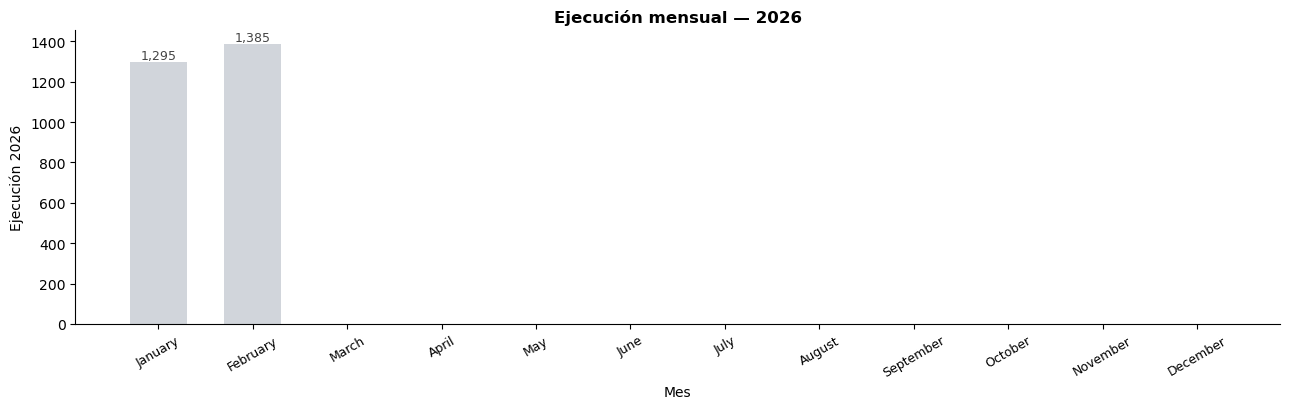

In [16]:
fig, ax = plt.subplots(figsize=(13, 4.2))

bars = ax.bar(MES_NOMBRES, ejecucion_mensual, color="#D1D5DB", width=0.6, label="Ejecución 2026")

# etiqueta sobre cada barra
for bar, v in zip(bars, ejecucion_mensual):
    if v > 0:
        ax.text(bar.get_x() + bar.get_width()/2, v, f"{v:,.0f}",
                ha="center", va="bottom", fontsize=9, color="#444")

ax.set_ylabel("Ejecución 2026")
ax.set_xlabel("Mes")
ax.set_title("Ejecución mensual — 2026", fontsize=12, fontweight="bold")
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="x", labelrotation=30, labelsize=9)
plt.tight_layout()
plt.show()

## 13. Gráfica de línea — Dato 2025 (referencia)

Es una constante horizontal = Σ `Línea Base 2025` con los filtros actuales. En el BI aparece sobre la gráfica de barras.

In [17]:
dato_2025 = float(f["Línea Base 2025"].sum())
print(f"Dato 2025 = {dato_2025:,.0f}")

Dato 2025 = 10,276


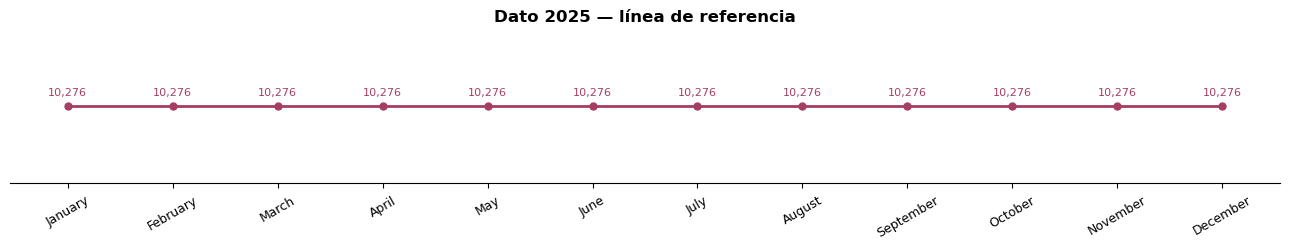

In [18]:
fig, ax = plt.subplots(figsize=(13, 2.6))
ax.plot(MES_NOMBRES, [dato_2025] * 12, color="#A43F5F", linewidth=2,
        marker="o", markersize=5, label="Dato 2025")
for i, n in enumerate(MES_NOMBRES):
    ax.annotate(f"{dato_2025:,.0f}", (n, dato_2025), textcoords="offset points",
                xytext=(0, 8), ha="center", fontsize=8, color="#A43F5F")
ax.set_title("Dato 2025 — línea de referencia", fontsize=12, fontweight="bold")
ax.spines[["top", "right", "left"]].set_visible(False)
ax.set_yticks([])
ax.tick_params(axis="x", labelrotation=30, labelsize=9)
plt.tight_layout()
plt.show()

## 14. Gráfica combinada (como aparece en el BI)

Barras de Ejecución 2026 + línea de Dato 2025 en el mismo plot.

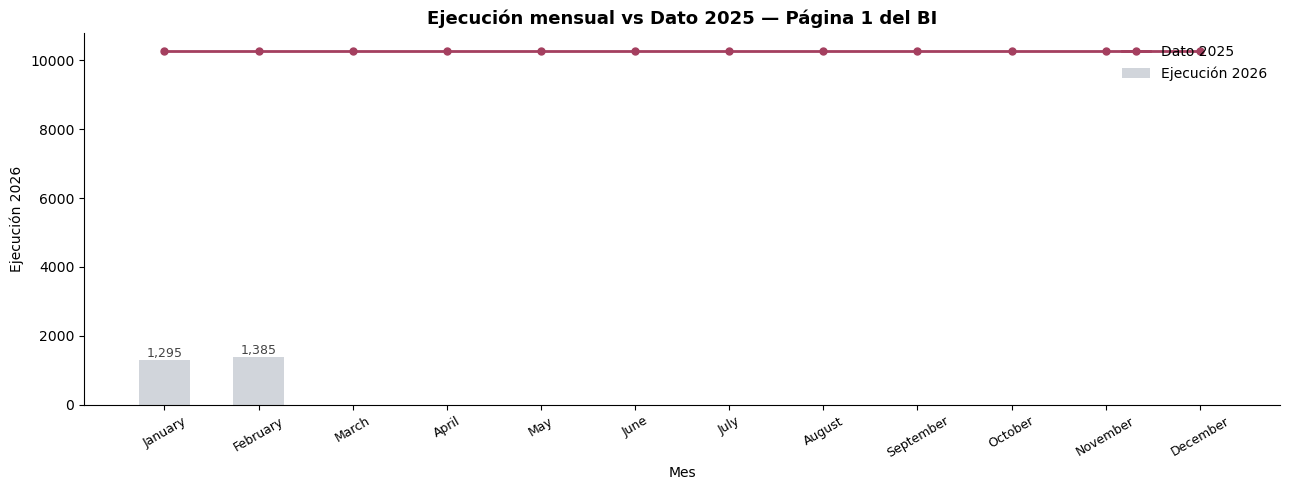

In [19]:
fig, ax = plt.subplots(figsize=(13, 5))

# Barras — ejecución mensual
bars = ax.bar(MES_NOMBRES, ejecucion_mensual, color="#D1D5DB", width=0.55, label="Ejecución 2026")
for bar, v in zip(bars, ejecucion_mensual):
    if v > 0:
        ax.text(bar.get_x() + bar.get_width()/2, v, f"{v:,.0f}",
                ha="center", va="bottom", fontsize=9, color="#444")

# Línea — dato 2025
ax.plot(MES_NOMBRES, [dato_2025] * 12, color="#A43F5F", linewidth=2,
        marker="o", markersize=5, label="Dato 2025")

ax.set_ylabel("Ejecución 2026")
ax.set_xlabel("Mes")
ax.set_title("Ejecución mensual vs Dato 2025 — Página 1 del BI",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper right", frameon=False)
ax.spines[["top", "right"]].set_visible(False)
ax.tick_params(axis="x", labelrotation=30, labelsize=9)
plt.tight_layout()
plt.show()

## 15. Validación final

Resumen de KPIs globales que se pueden contrastar contra el BI.

In [20]:
resumen = pd.Series({
    "Total Meta":            f["Meta"].sum(),
    "Total Avance":          f["Avance Total"].sum(),
    "Total Dato 2025":       f["Línea Base 2025"].sum(),
    "% Avance global":       f["Avance Total"].sum() / f["Meta"].sum() * 100 if f["Meta"].sum() else 0,
    "PRBs únicos":           f["CodPRB"].nunique(),
    "Indicadores únicos":    f["Cod_Indicador"].nunique(),
    "Filas procesadas":      len(f),
})
resumen.round(2)

Total Meta            66971.1
Total Avance           2680.0
Total Dato 2025       10276.0
% Avance global           4.0
PRBs únicos              96.0
Indicadores únicos       13.0
Filas procesadas       1248.0
dtype: float64

✅ **Estos valores deben coincidir con los que muestra el BI oficial** cuando se abre con los filtros por defecto (AÑO=2026, todo lo demás sin filtrar).

Para validar también contra la implementación backend del dashboard UBPD puedes llamar al endpoint público:

```
GET /api/bi/kpis?anio=2026
```

y comparar.